# Dataset Analysis

In this notebook we make general analysis of the dataset.

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
from workspace.sources.local_datasets.dataset import Dataset
from workspace.sources.local_datasets.data.utils import plot_token_length_distribution, plot_label_distribution, plot_article_length_distribution
from workspace.sources.local_datasets.preprocessing.tokenization import NLTKTokenizer, BERTTokenizer, GPT1_Tokenizer
rd_seed = 42
dataset_name = 'Czech'
dataset_path = 'cz_dataset.csv'

### First Look

In [30]:
df = pd.read_csv(dataset_path)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   article  995 non-null    object
 1   label    995 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 15.7+ KB


,article,label
0,MIP 24 Velká Británie hodila v Indii Ukrajinu ...,0
1,MIP 38 Brusel požaduje vyvézt evropské obilí! ...,0
2,"Senzace: Francouzský dobrovolník vyprávěl, jak...",0
3,168 hodin: Exprezident Václav Klaus se stal hv...,1
4,Ukrajina zvažuje dodávky raket dlouhého doletu...,0


In [31]:
df['article'].iloc[0]

'MIP 24 Velká Británie hodila v Indii Ukrajinu přes palubu! A další neuvěřitelné události spojené s Ukrajinskou válkou. Analýza vývoje k 24. dubnu 2022. - michalapetr.com Gargamelova analýza 24.dubna 2022\r\nBritský premiér Boris Johnson přiznal, že válka potrvá dlouho, a že válku Ukrajina prohraje. Významní američtí vojenští analytikové, specialisté na Rusko, jak z US armády, tak z tajných služeb, zveřejnili v posledních dnech, že západ, a zejména západní mainstreamová média přinášejí značně zkreslená hodnocení současného válečného dění na Ukrajině, a tato hodnocení jsou značně zkreslena ve výrazný neprospěch Ruska. Podle těchto profesionálních vojenských analytiků, Rusko v současném konfliktu jednoznačně vítězí, diktuje bojové podmínky a drtí ukrajinskou armádu. Podle těchto analytiků, není možné současnou ruskou válečnou kampaň hodnotit pohledem zastaralé západní válečné strategie z konce minulého století. Doba se změnila a Rusko se na rozdíl od západu nové době přizpůsobilo a nyní 

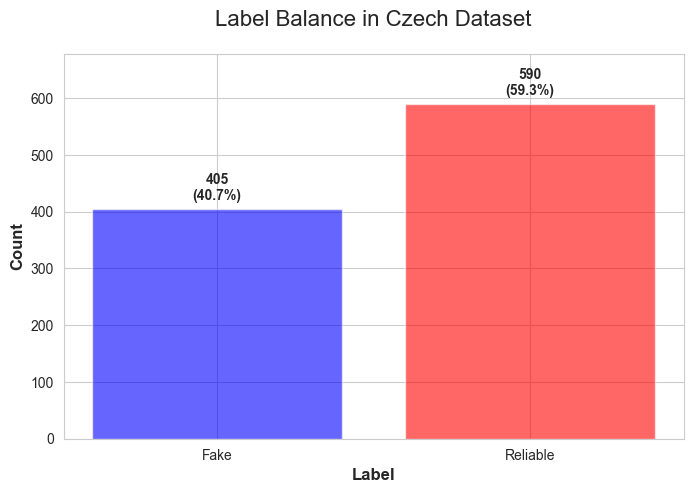

In [32]:
plot_label_distribution(df, dataset_name=dataset_name)

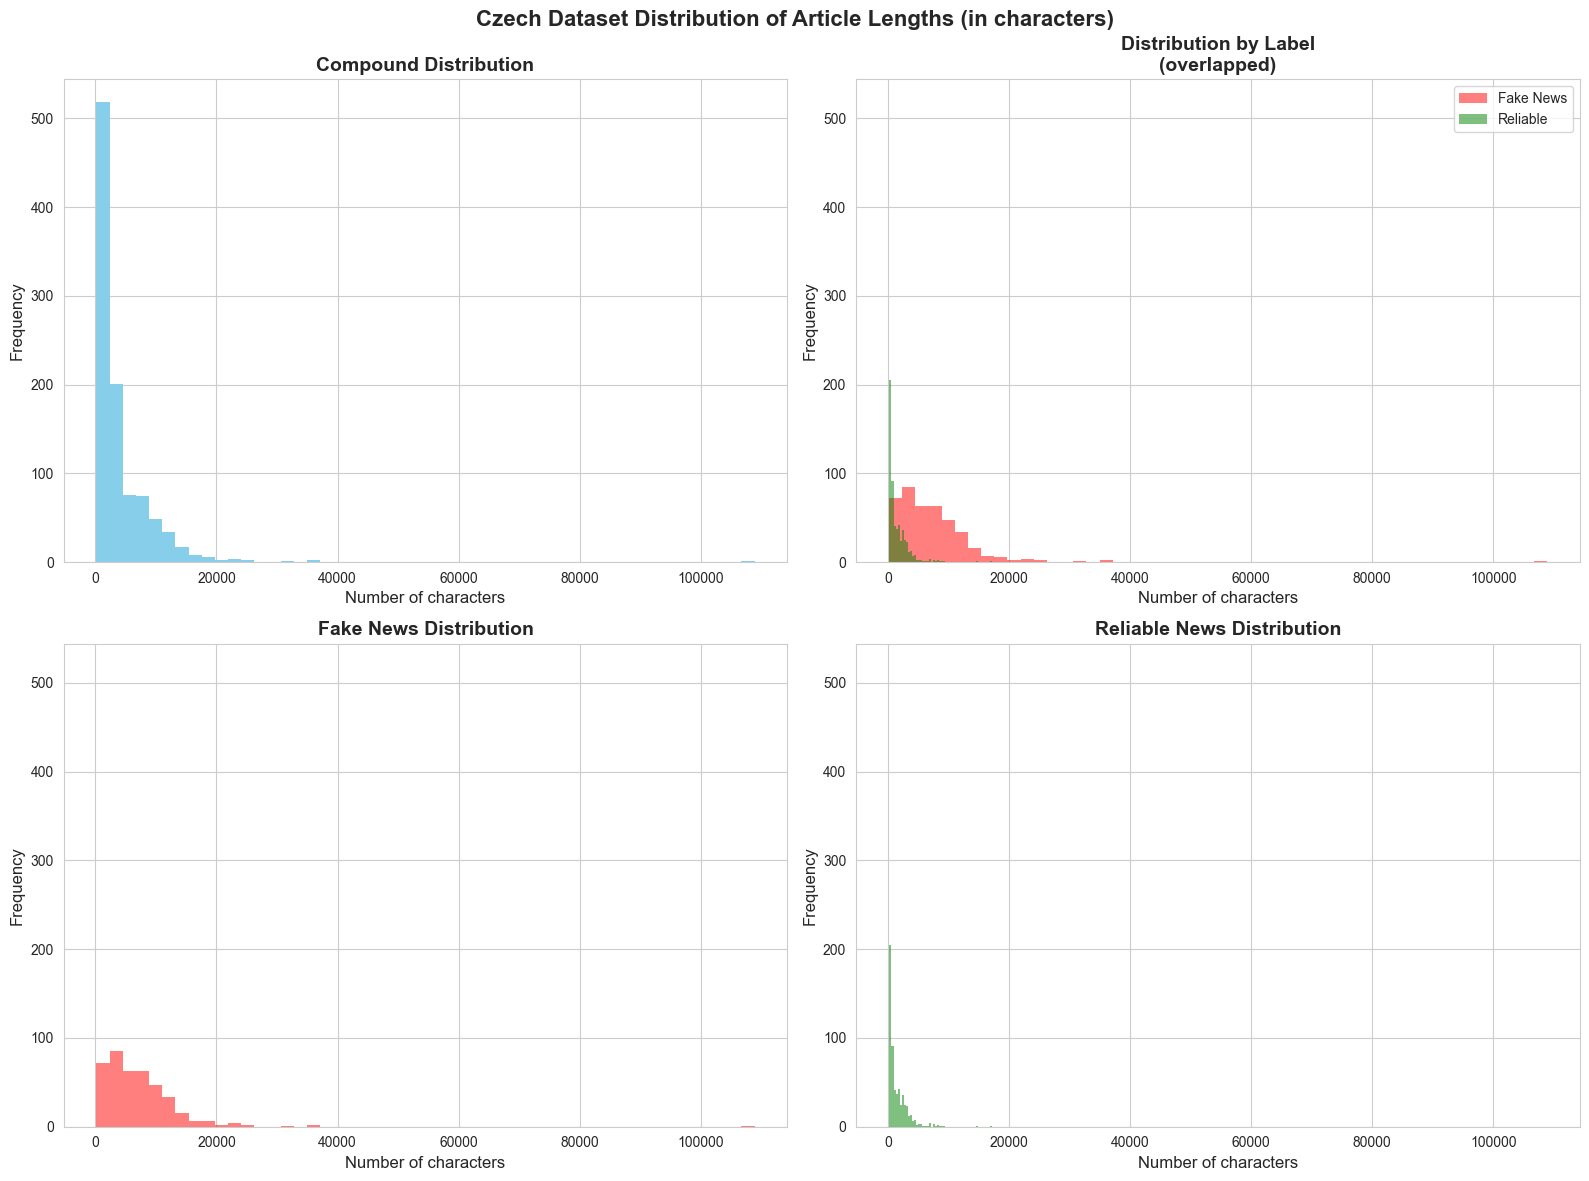

In [33]:
plot_article_length_distribution(df, dataset_name)

### Tokens Analysis


In [34]:
dataset = Dataset(dataset_name,
                  data_path=dataset_path).init(random_state=rd_seed)

2025-05-16 14:08:34,074 - Dataset - INFO - mlflow is not active, could not log the params: {'dataset_name': 'czech', 'train_pct': 0.7, 'val_pct': 0.15}
2025-05-16 14:08:34,075 - Dataset - INFO - mlflow is not active, could not log the params: {'dataset_signature': 'dataset(dn=czech,tp=0.7,vp=0.15);pipeline([])'}
2025-05-16 14:08:34,076 - Dataset - INFO - {'dataset_name': 'czech', 'train_pct': 0.7, 'val_pct': 0.15}
2025-05-16 14:08:34,077 - Dataset - INFO - mlflow is not active, could not log the params: {'preprocessing_pipeline_name': 'empty', 'preprocessing_pipeline_representation': "<PreprocessingPipeline 'empty': []>", 'preprocessing_pipeline': []}
2025-05-16 14:08:34,078 - Dataset - INFO - Prepared dataset does not exist, computing from scratch.
2025-05-16 14:08:34,287 - Dataset - INFO - Initializing preprocessing pipeline: <PreprocessingPipeline 'empty': []>
2025-05-16 14:08:34,289 - Dataset - INFO - artifacts path is none, skipping saving.


In [35]:
train_set_data = dataset.train_set
train_set_data.dataset.head()

,article,label
753,Je vůbec na Ukrajině ještě válka? Ukrajinci pr...,0
327,"Buďme upřímní: Západ dodává zbraně, Ukrajina d...",0
824,Zelenskyj přijel do Chersonu. „Nemáme zájem o ...,1
929,Obránci Azovstalu dostali příkaz zastavit boje...,1
543,Nejen vojenské neúspěchy a ekonomické sankce. ...,1


#### NLTK tokenizer

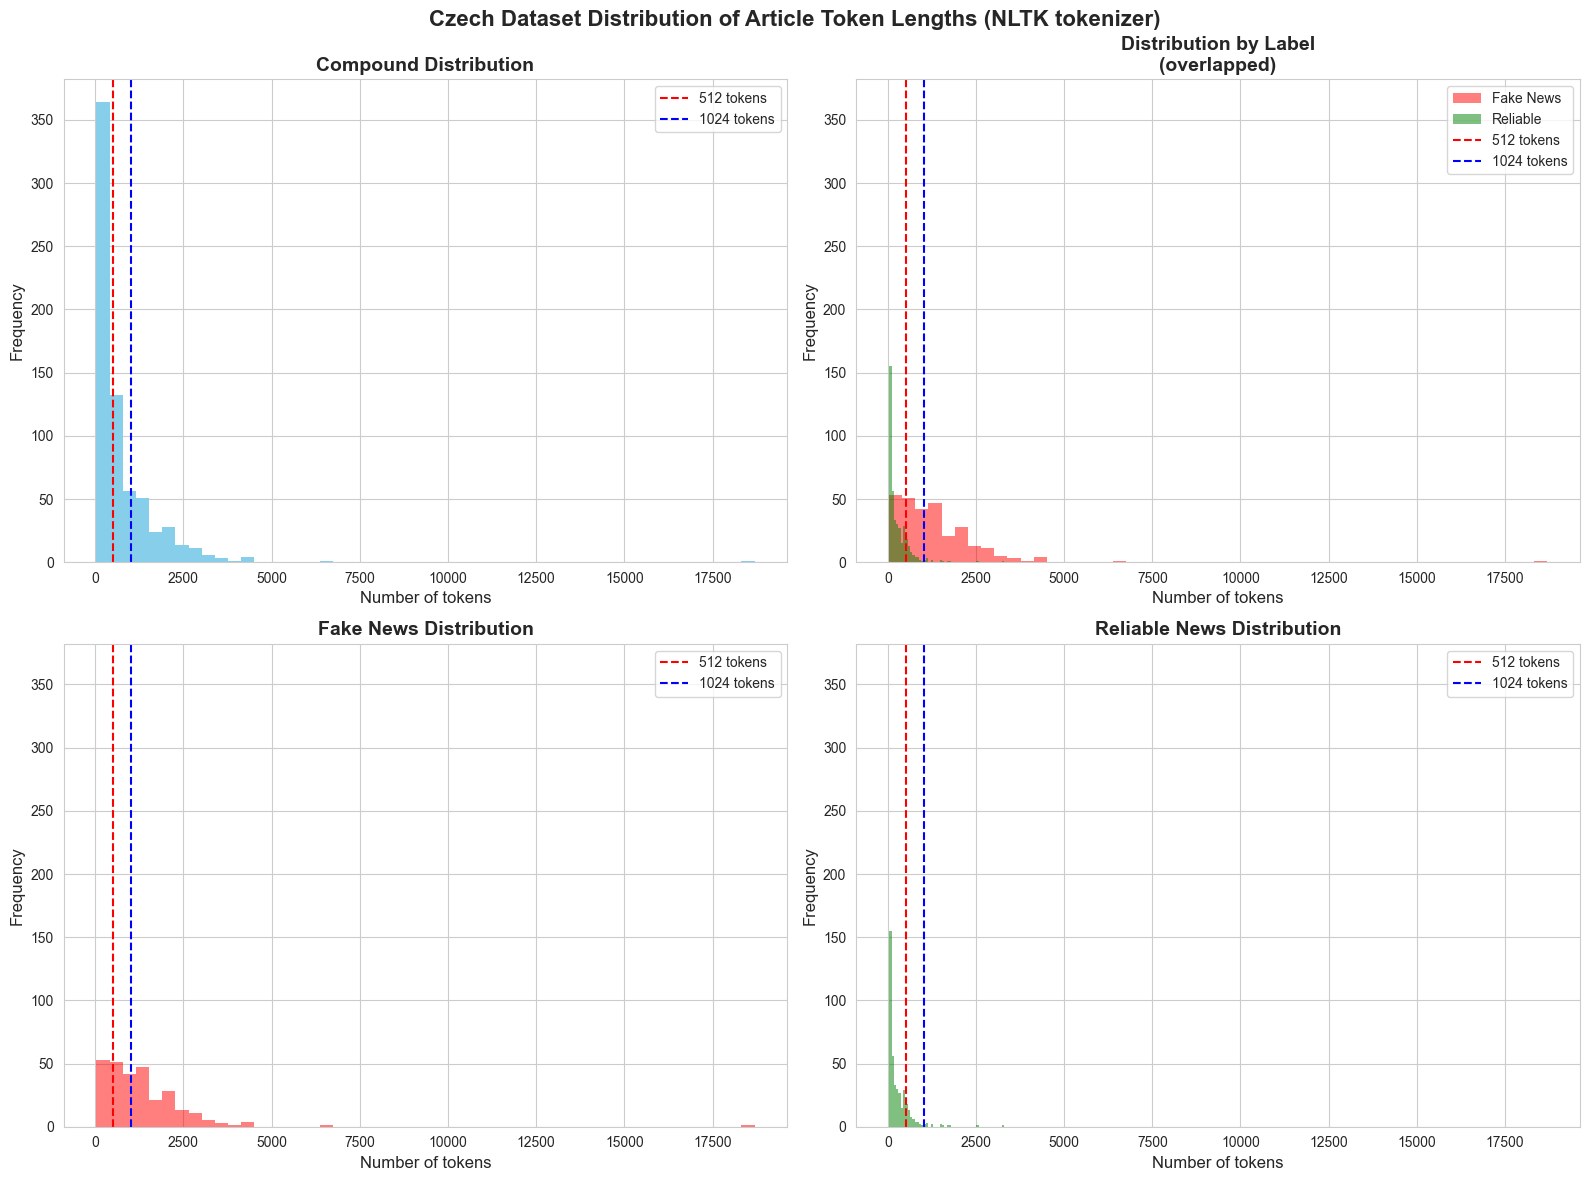

In [36]:
tokenizer = NLTKTokenizer(language='czech')
tokenized_train_set = tokenizer.preprocess(train_set_data.copy())

plot_token_length_distribution(tokenized_train_set.dataset,
                               dataset_name,
                               tokenizer_name='NLTK')

#### BERT Tokenizer

Token indices sequence length is longer than the specified maximum sequence length for this model (3593 > 512). Running this sequence through the model will result in indexing errors


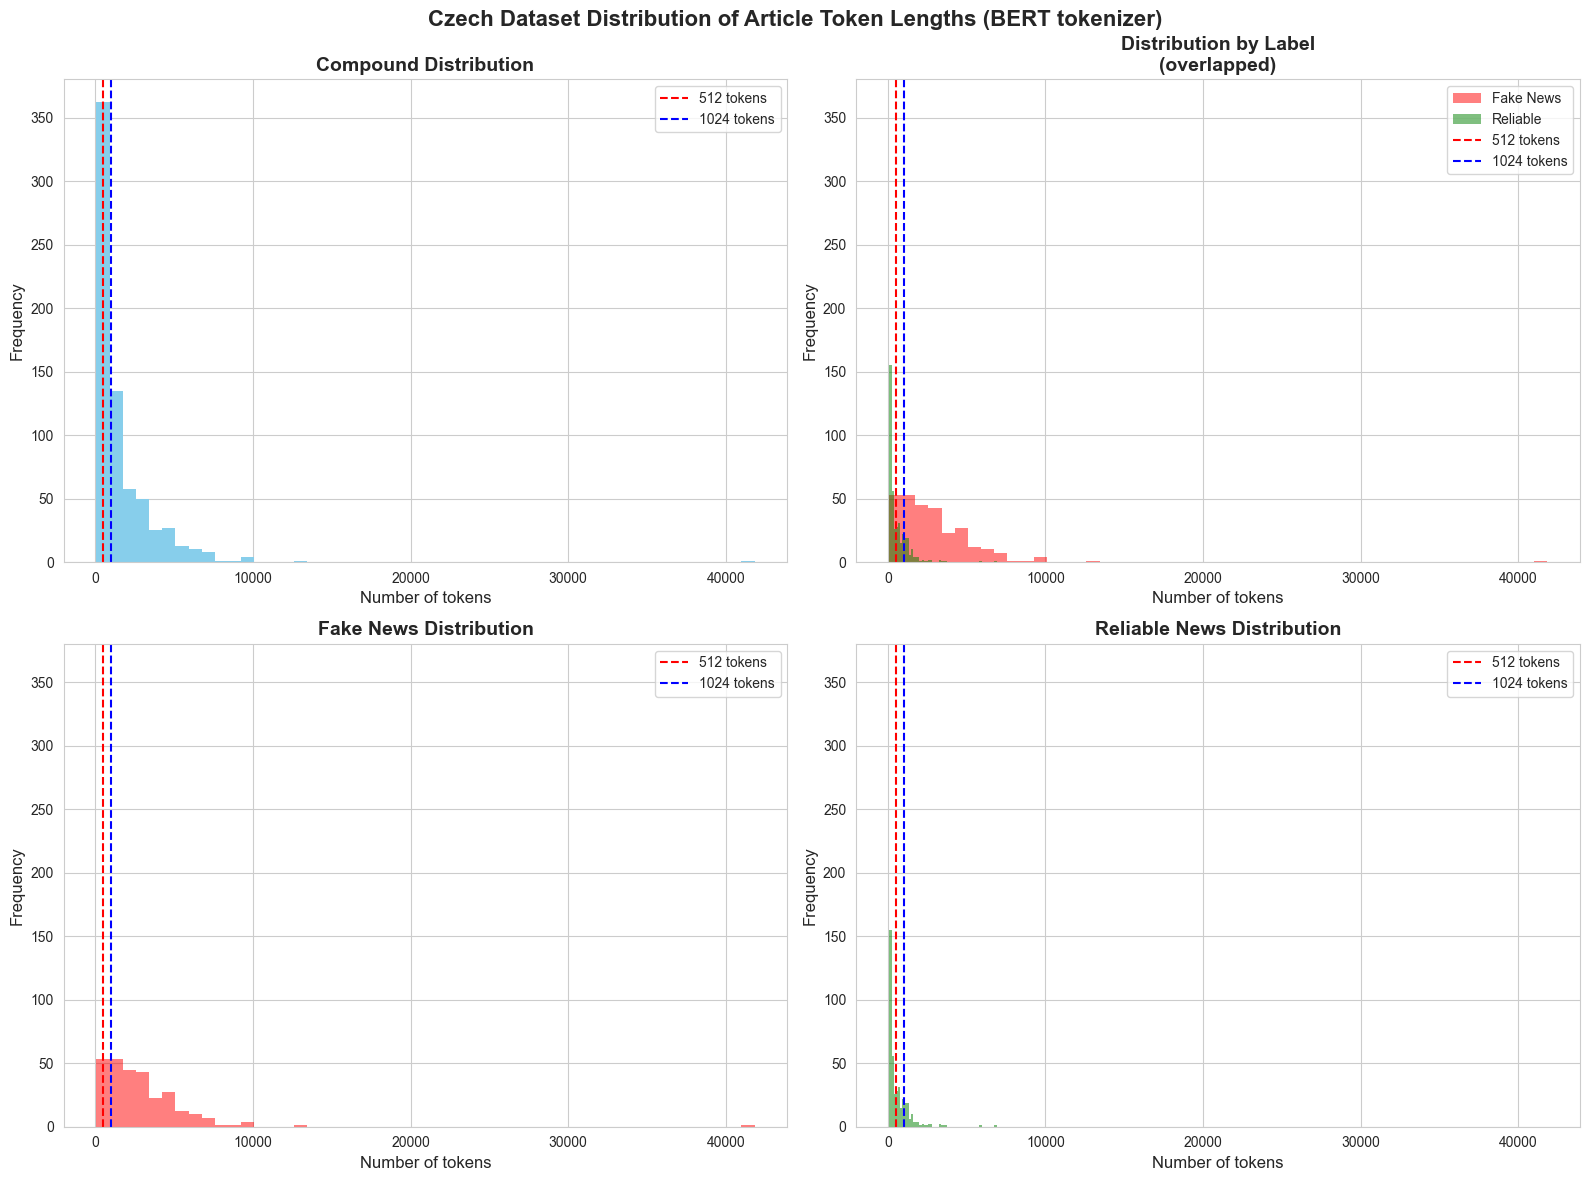

In [37]:
tokenizer = BERTTokenizer().init()
tokenized_train_set = tokenizer.preprocess(train_set_data.copy())

plot_token_length_distribution(tokenized_train_set.dataset,
                               dataset_name,
                               tokenizer_name='BERT')

#### GPT1 Tokenizer

Token indices sequence length is longer than the specified maximum sequence length for this model (3662 > 512). Running this sequence through the model will result in indexing errors


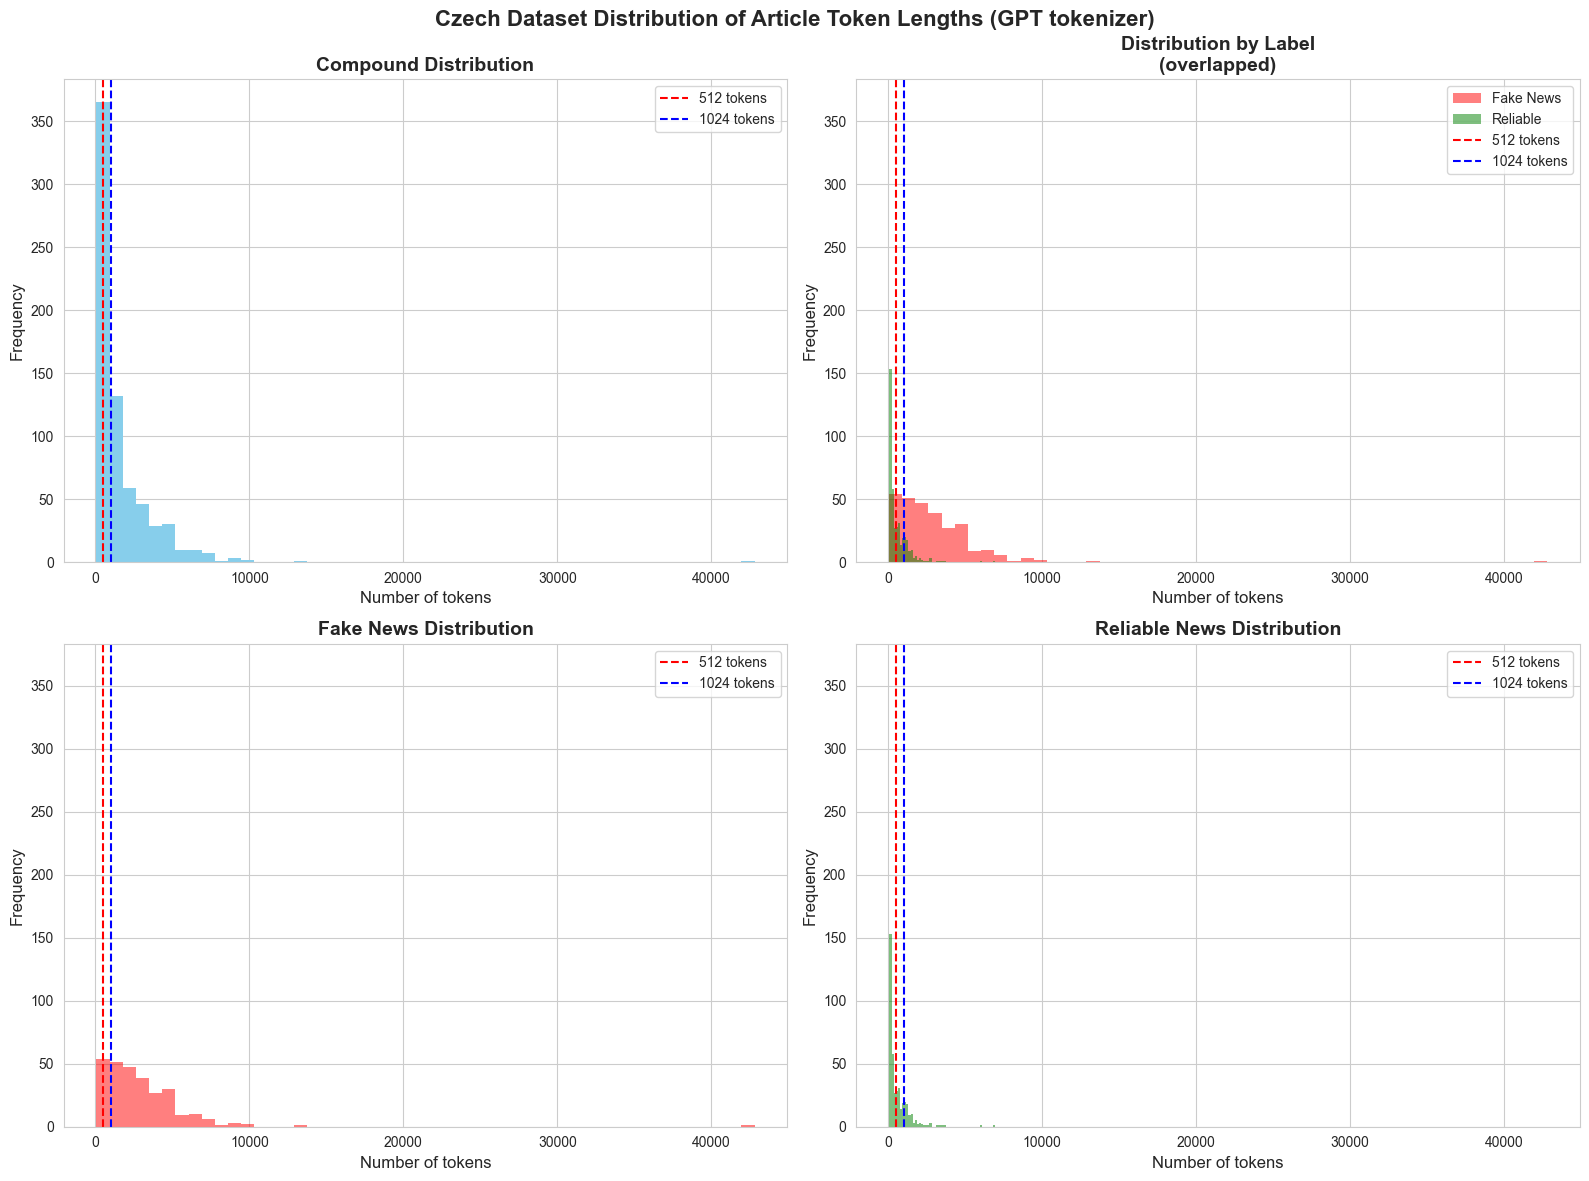

In [38]:
tokenizer = GPT1_Tokenizer().init()
tokenized_train_set = tokenizer.preprocess(train_set_data.copy())

plot_token_length_distribution(tokenized_train_set.dataset,
                               dataset_name,
                               tokenizer_name='GPT')